# Car Price Prediction: Comparative Analysis of Regression Models

## Introduction
This notebook presents a comprehensive study comparing multiple regression models for car price prediction using real data from a DuckDB database. We focus on the car model with the most records to ensure robust model training and validation.

**Models evaluated:**
- Gradient Boosting Regressor
- Random Forest Regressor  
- Linear Regression
- Exponential Curve Fitting
- Mixed Exponential-Linear Model (Weighted Ensemble)

The data is split into training (70%) and testing (30%) sets for proper validation, and we evaluate model performance using Mean Squared Error (MSE) and R² metrics.

In [59]:
# Import required libraries
import sys
import os
sys.path.append(os.path.abspath('../src'))
from data.database import get_car_items
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from scipy.optimize import curve_fit

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

## Load data from duckdb (leboncoin.fr)

In [60]:
# Load data using database.py
df = get_car_items()
df = df.dropna(subset=['model', 'age_in_days', 'mileage', 'price'])
train_df, test_df = train_test_split(df, test_size=0.3, random_state=42)
print(f"Total records: {len(df)}")
print(f"Training records: {len(train_df)}")
print(f"Testing records: {len(test_df)}")

Total records: 14122
Training records: 9885
Testing records: 4237


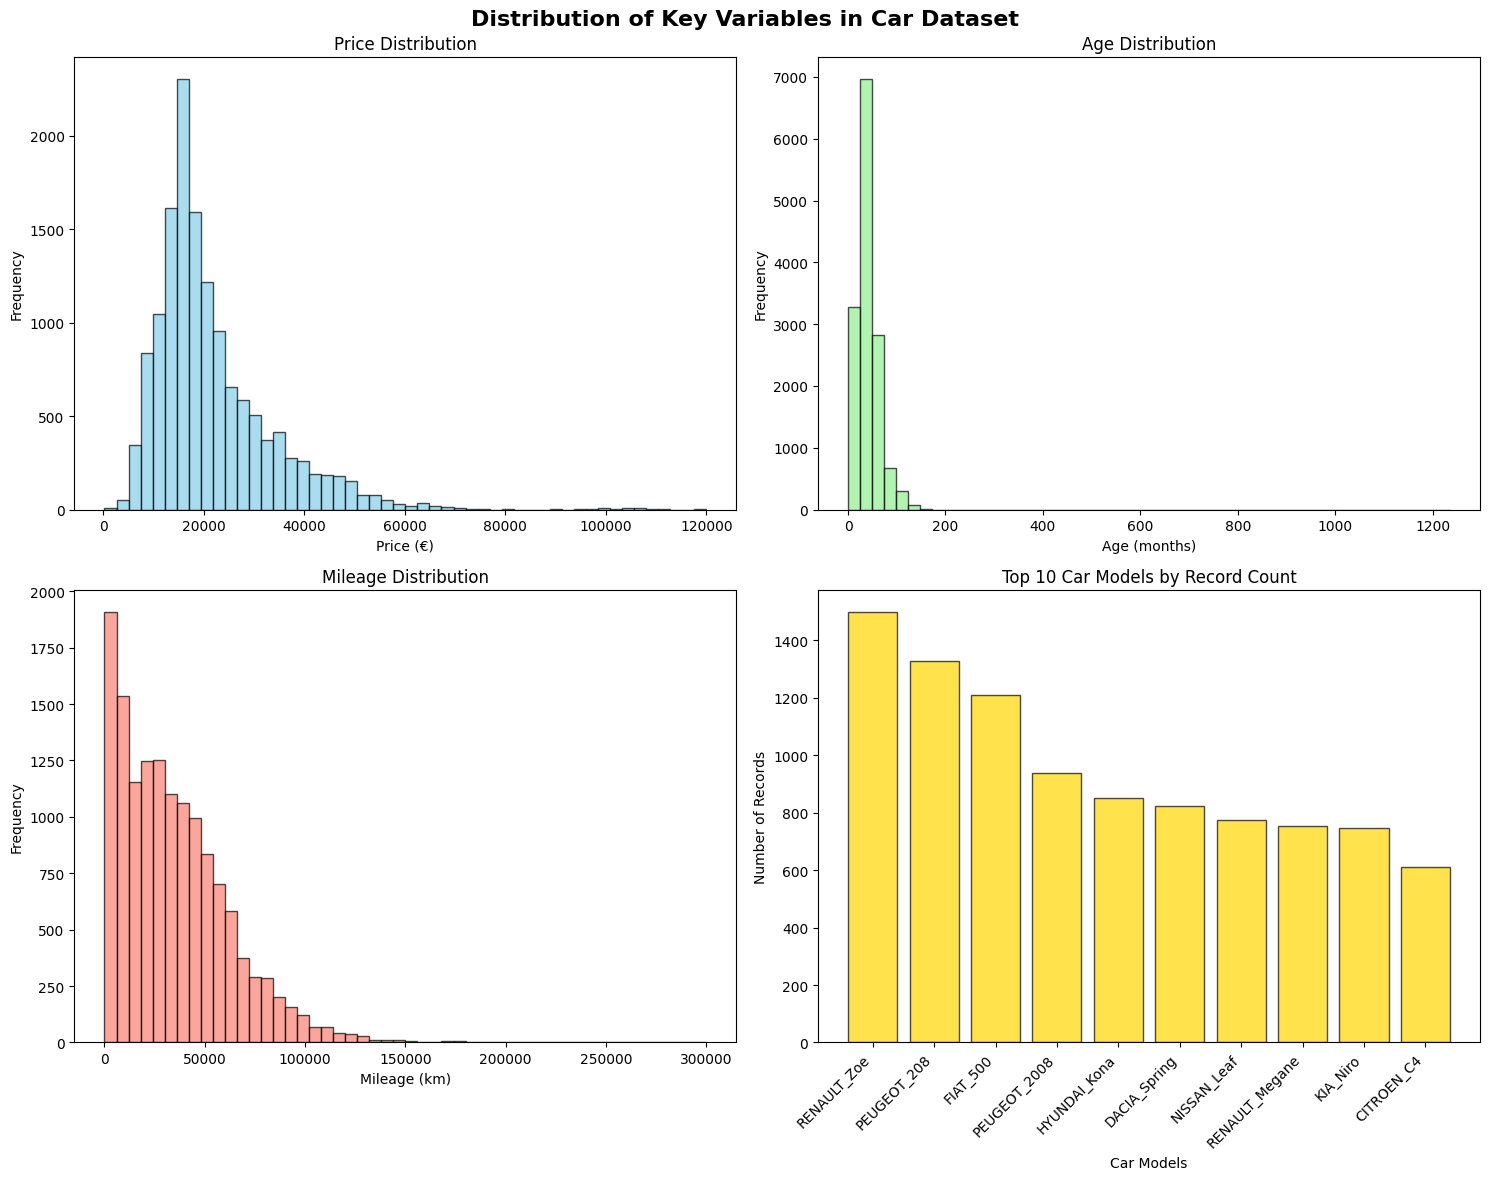

Dataset Basic Statistics:
Shape: (14122, 4)
Number of unique car models: 112

Numerical variables summary:
               price   age_in_days        mileage
count   14122.000000  14122.000000   14122.000000
mean    21686.344286   1227.362272   34904.366804
std     11961.074304    775.106045   27858.077756
min       249.000000      9.000000       1.000000
25%     13990.000000    801.000000   12500.000000
50%     18289.500000   1197.000000   30000.000000
75%     26490.000000   1562.000000   50240.750000
max    119990.000000  37599.000000  300000.000000

Age range in months: 0.3 to 1235.2


In [61]:
# Data exploration: Visualize the distribution of key variables
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Distribution of Key Variables in Car Dataset', fontsize=16, fontweight='bold')

# Price distribution
axes[0, 0].hist(df['price'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Price Distribution')
axes[0, 0].set_xlabel('Price (€)')
axes[0, 0].set_ylabel('Frequency')

# Age distribution (convert days to months)
age_in_months = df['age_in_days'] / 30.44  # Average days per month
axes[0, 1].hist(age_in_months, bins=50, alpha=0.7, color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Age Distribution')
axes[0, 1].set_xlabel('Age (months)')
axes[0, 1].set_ylabel('Frequency')

# Mileage distribution
axes[1, 0].hist(df['mileage'], bins=50, alpha=0.7, color='salmon', edgecolor='black')
axes[1, 0].set_title('Mileage Distribution')
axes[1, 0].set_xlabel('Mileage (km)')
axes[1, 0].set_ylabel('Frequency')

# Top 10 car models
top_models = df['model'].value_counts().head(10)
axes[1, 1].bar(range(len(top_models)), top_models.values, alpha=0.7, color='gold', edgecolor='black')
axes[1, 1].set_title('Top 10 Car Models by Record Count')
axes[1, 1].set_xlabel('Car Models')
axes[1, 1].set_ylabel('Number of Records')
axes[1, 1].set_xticks(range(len(top_models)))
axes[1, 1].set_xticklabels(top_models.index, rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Display basic statistics
print("Dataset Basic Statistics:")
print(f"Shape: {df.shape}")
print(f"Number of unique car models: {df['model'].nunique()}")
print("\nNumerical variables summary:")
print(df[['price', 'age_in_days', 'mileage']].describe())
print(f"\nAge range in months: {(df['age_in_days'] / 30.44).min():.1f} to {(df['age_in_days'] / 30.44).max():.1f}")

In [62]:
# Focus the study on the car model with the most records, excluding RENAULT_Zoe (because of the battery rental)
model_counts = train_df['model'].value_counts()

# Exclude RENAULT_Zoe from consideration
model_counts_filtered = model_counts[model_counts.index != 'RENAULT_Zoe']

# Get the top model after filtering
top_model = model_counts_filtered.idxmax()
print(f"Model counts (top 5):")
print(model_counts.head())
print(f"\nExcluding RENAULT_Zoe from analysis due to battery rental pricing model")
print(f"Focusing analysis on car model: {top_model}")
print(f"Records for {top_model}: {model_counts_filtered.iloc[0]}")

train_df_top = train_df[train_df['model'] == top_model].copy()
test_df_top = test_df[test_df['model'] == top_model].copy()

Model counts (top 5):
model
RENAULT_Zoe     1041
PEUGEOT_208      936
FIAT_500         860
PEUGEOT_2008     664
HYUNDAI_Kona     615
Name: count, dtype: int64

Excluding RENAULT_Zoe from analysis due to battery rental pricing model
Focusing analysis on car model: PEUGEOT_208
Records for PEUGEOT_208: 936


## Price Analysis for Selected Model
Detailed visualization of price patterns for the selected car model to understand the relationship between price, age, and mileage.

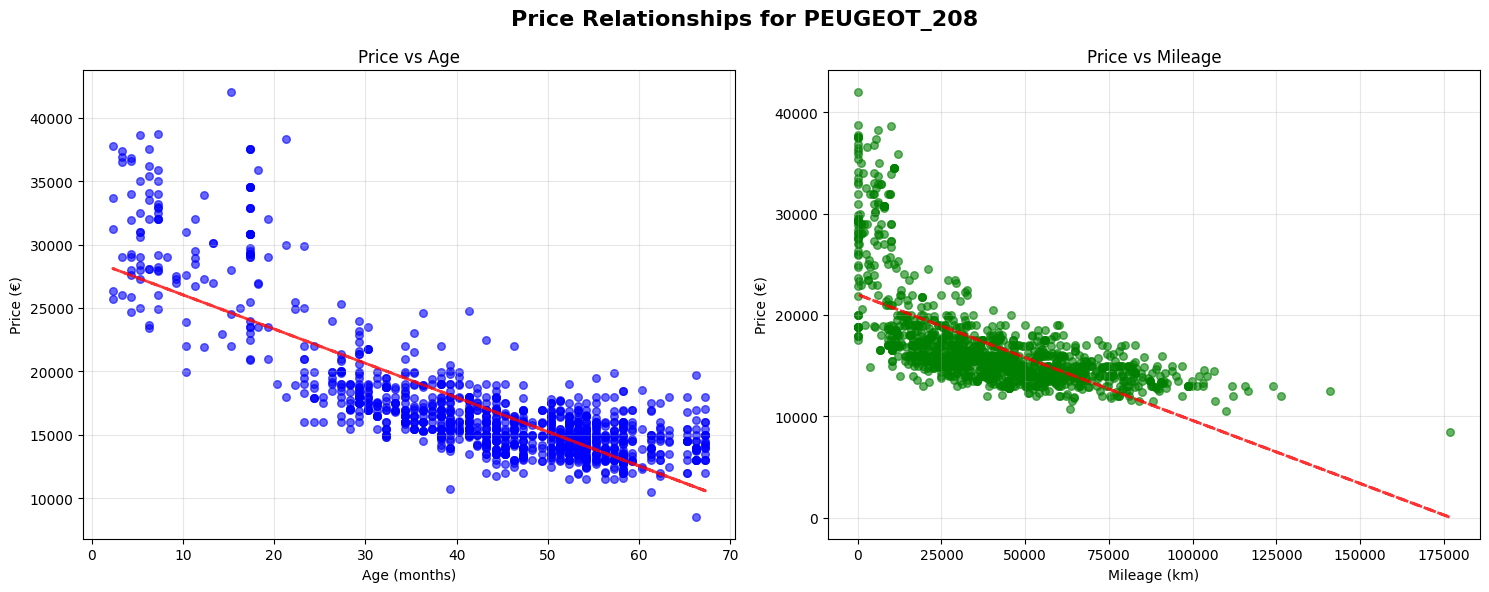

Correlation between price and age (months): -0.804
Correlation between price and mileage: -0.628
Total records for PEUGEOT_208: 1327


In [63]:
# Create scatter plots to visualize price relationships
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f'Price Relationships for {top_model}', fontsize=16, fontweight='bold')

# Combined training and test data for visualization
combined_data = pd.concat([train_df_top, test_df_top])

# Price vs Age scatter plot
age_months = combined_data['age_in_days'] / 30.44
axes[0].scatter(age_months, combined_data['price'], alpha=0.6, color='blue', s=30)
axes[0].set_xlabel('Age (months)')
axes[0].set_ylabel('Price (€)')
axes[0].set_title('Price vs Age')
axes[0].grid(True, alpha=0.3)

# Add trend line
z = np.polyfit(age_months, combined_data['price'], 1)
p = np.poly1d(z)
axes[0].plot(age_months, p(age_months), "r--", alpha=0.8, linewidth=2)

# Price vs Mileage scatter plot
axes[1].scatter(combined_data['mileage'], combined_data['price'], alpha=0.6, color='green', s=30)
axes[1].set_xlabel('Mileage (km)')
axes[1].set_ylabel('Price (€)')
axes[1].set_title('Price vs Mileage')
axes[1].grid(True, alpha=0.3)

# Add trend line
z2 = np.polyfit(combined_data['mileage'], combined_data['price'], 1)
p2 = np.poly1d(z2)
axes[1].plot(combined_data['mileage'], p2(combined_data['mileage']), "r--", alpha=0.8, linewidth=2)

plt.tight_layout()
plt.show()

# Print correlation coefficients
print(f"Correlation between price and age (months): {combined_data['price'].corr(age_months):.3f}")
print(f"Correlation between price and mileage: {combined_data['price'].corr(combined_data['mileage']):.3f}")
print(f"Total records for {top_model}: {len(combined_data)}")

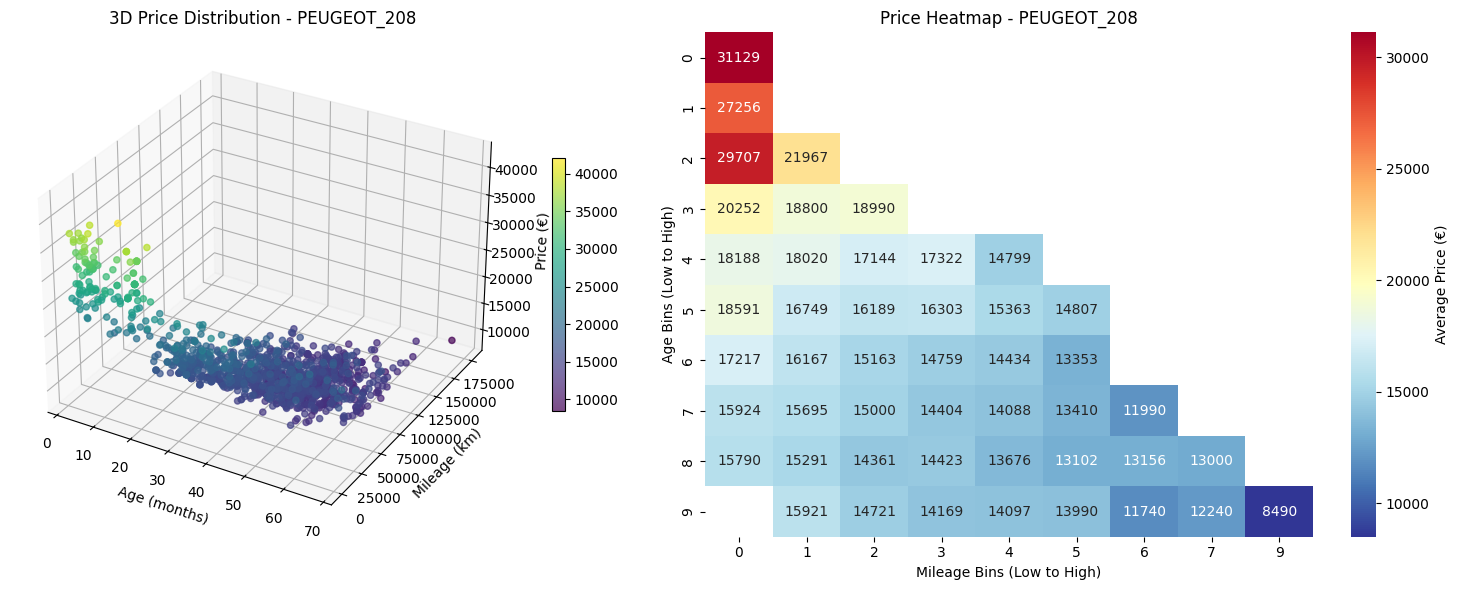

In [64]:
# Create a 3D scatter plot and heatmap for better visualization
fig = plt.figure(figsize=(16, 6))

# 3D scatter plot
ax1 = fig.add_subplot(121, projection='3d')
age_months_3d = combined_data['age_in_days'] / 30.44
scatter = ax1.scatter(age_months_3d, combined_data['mileage'], combined_data['price'], 
                     c=combined_data['price'], cmap='viridis', alpha=0.7, s=20)
ax1.set_xlabel('Age (months)')
ax1.set_ylabel('Mileage (km)')
ax1.set_zlabel('Price (€)')
ax1.set_title(f'3D Price Distribution - {top_model}')
plt.colorbar(scatter, ax=ax1, shrink=0.5)

# Create bins for heatmap
age_bins = pd.cut(age_months_3d, bins=10, labels=False)
mileage_bins = pd.cut(combined_data['mileage'], bins=10, labels=False)

# Calculate average price for each bin combination
heatmap_data = combined_data.groupby([age_bins, mileage_bins])['price'].mean().unstack()

# Heatmap
ax2 = fig.add_subplot(122)
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='RdYlBu_r', ax=ax2, 
            cbar_kws={'label': 'Average Price (€)'})
ax2.set_title(f'Price Heatmap - {top_model}')
ax2.set_xlabel('Mileage Bins (Low to High)')
ax2.set_ylabel('Age Bins (Low to High)')

plt.tight_layout()
plt.show()

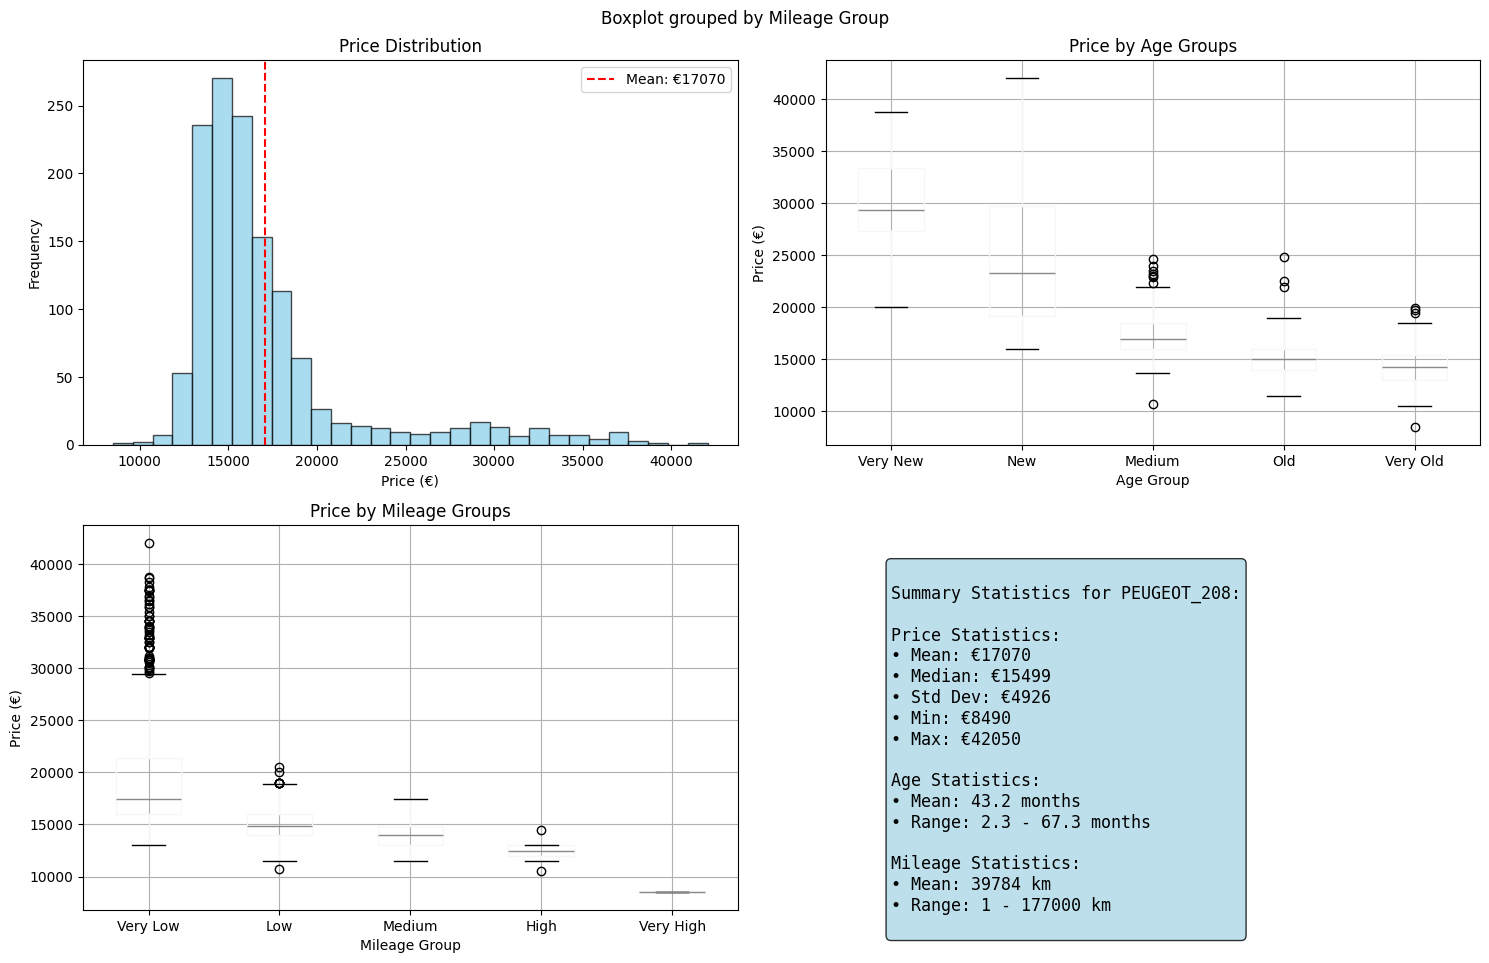

In [65]:
# Price distribution and box plots for the selected model
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle(f'Detailed Price Analysis - {top_model}', fontsize=16, fontweight='bold')

# Price histogram
axes[0, 0].hist(combined_data['price'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Price Distribution')
axes[0, 0].set_xlabel('Price (€)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(combined_data['price'].mean(), color='red', linestyle='--', 
                   label=f'Mean: €{combined_data["price"].mean():.0f}')
axes[0, 0].legend()

# Age vs Price box plot (binned)
age_months_binned = pd.cut(age_months_3d, bins=5, labels=['Very New', 'New', 'Medium', 'Old', 'Very Old'])
age_price_df = pd.DataFrame({'Age Group': age_months_binned, 'Price': combined_data['price']})
age_price_df.boxplot(column='Price', by='Age Group', ax=axes[0, 1])
axes[0, 1].set_title('Price by Age Groups')
axes[0, 1].set_xlabel('Age Group')
axes[0, 1].set_ylabel('Price (€)')

# Mileage vs Price box plot (binned)
mileage_binned = pd.cut(combined_data['mileage'], bins=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
mileage_price_df = pd.DataFrame({'Mileage Group': mileage_binned, 'Price': combined_data['price']})
mileage_price_df.boxplot(column='Price', by='Mileage Group', ax=axes[1, 0])
axes[1, 0].set_title('Price by Mileage Groups')
axes[1, 0].set_xlabel('Mileage Group')
axes[1, 0].set_ylabel('Price (€)')

# Summary statistics table as text
axes[1, 1].axis('off')
summary_text = f"""
Summary Statistics for {top_model}:

Price Statistics:
• Mean: €{combined_data['price'].mean():.0f}
• Median: €{combined_data['price'].median():.0f}
• Std Dev: €{combined_data['price'].std():.0f}
• Min: €{combined_data['price'].min():.0f}
• Max: €{combined_data['price'].max():.0f}

Age Statistics:
• Mean: {age_months_3d.mean():.1f} months
• Range: {age_months_3d.min():.1f} - {age_months_3d.max():.1f} months

Mileage Statistics:
• Mean: {combined_data['mileage'].mean():.0f} km
• Range: {combined_data['mileage'].min():.0f} - {combined_data['mileage'].max():.0f} km
"""
axes[1, 1].text(0.1, 0.9, summary_text, transform=axes[1, 1].transAxes, fontsize=12,
                verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.tight_layout()
plt.show()

## Training a few models

### Training: Gradient Boosting Regression
Train a Gradient Boosting regressor for the top car model and validate its performance.

In [66]:
# Train a GradientBoostingRegressor for the car model with the most records
X_train = train_df_top[['age_in_days', 'mileage']]
y_train = train_df_top['price']
X_test = test_df_top[['age_in_days', 'mileage']]
y_test = test_df_top['price']

gb_reg = GradientBoostingRegressor()
gb_reg.fit(X_train, y_train)

# Predict and validate on test set for the top car model
y_pred = gb_reg.predict(X_test)
gb_mse = mean_squared_error(y_test, y_pred)
gb_r2 = r2_score(y_test, y_pred)
print(f"Gradient Boosting: MSE={gb_mse:.2f}, R2={gb_r2:.2f}")

Gradient Boosting: MSE=4199394.77, R2=0.84


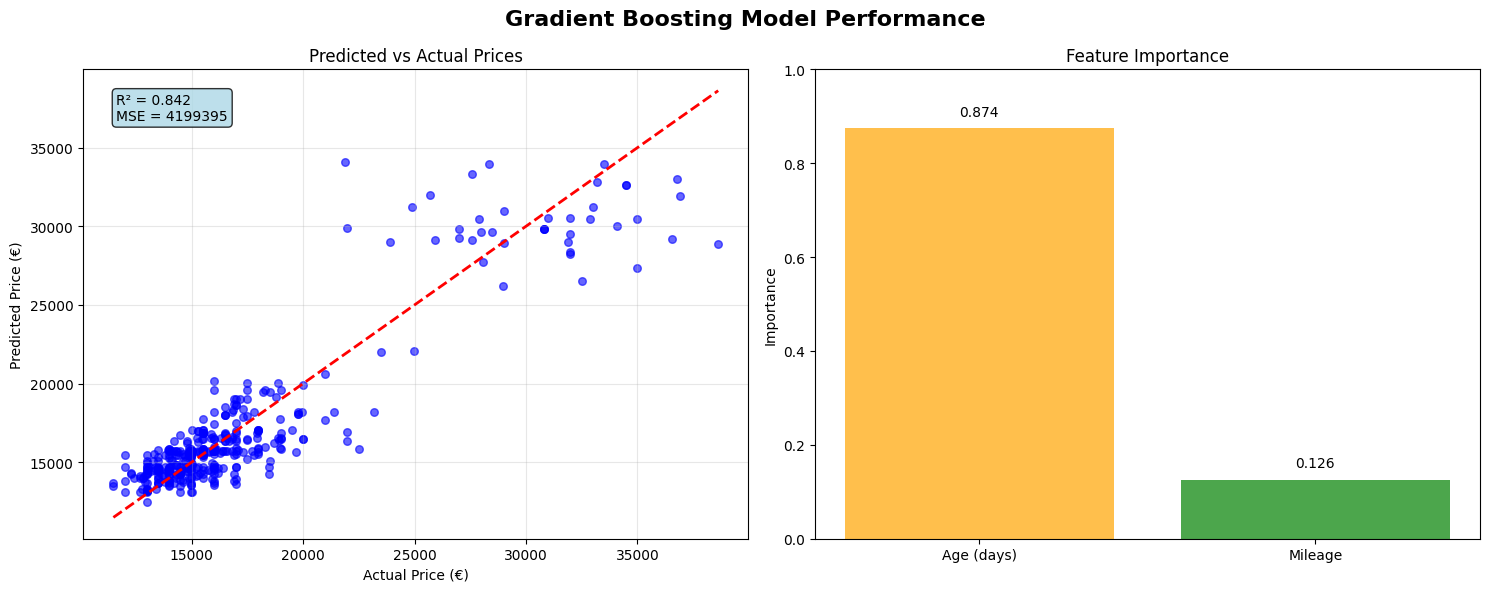

In [67]:
# Visualize Gradient Boosting model performance
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Gradient Boosting Model Performance', fontsize=16, fontweight='bold')

# Ensure we use the right data format for Gradient Boosting (DataFrame)
X_test_gb = test_df_top[['age_in_days', 'mileage']]
y_test_gb = test_df_top['price']

# Predicted vs Actual scatter plot
y_pred_gb = gb_reg.predict(X_test_gb)
axes[0].scatter(y_test_gb, y_pred_gb, alpha=0.6, color='blue', s=30)
axes[0].plot([y_test_gb.min(), y_test_gb.max()], [y_test_gb.min(), y_test_gb.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Price (€)')
axes[0].set_ylabel('Predicted Price (€)')
axes[0].set_title('Predicted vs Actual Prices')
axes[0].grid(True, alpha=0.3)
axes[0].text(0.05, 0.95, f'R² = {gb_r2:.3f}\nMSE = {gb_mse:.0f}', 
             transform=axes[0].transAxes, bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8),
             verticalalignment='top')

# Feature importance
feature_importance = gb_reg.feature_importances_
feature_names = ['Age (days)', 'Mileage']
axes[1].bar(feature_names, feature_importance, color=['orange', 'green'], alpha=0.7)
axes[1].set_title('Feature Importance')
axes[1].set_ylabel('Importance')
axes[1].set_ylim(0, 1)
for i, v in enumerate(feature_importance):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Training: Random Forest Regression
Train a Random Forest regressor for the top car model and evaluate its performance.

In [68]:
# Random Forest Regression for the top car model
X_train = train_df_top[['mileage', 'age_in_days']].values
y_train = train_df_top['price'].values
X_test = test_df_top[['mileage', 'age_in_days']].values
y_test = test_df_top['price'].values

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
rf_mse = mean_squared_error(y_test, y_pred)
rf_r2 = r2_score(y_test, y_pred)
print(f"Random Forest: MSE={rf_mse:.2f}, R2={rf_r2:.2f}")

Random Forest: MSE=4474936.10, R2=0.83


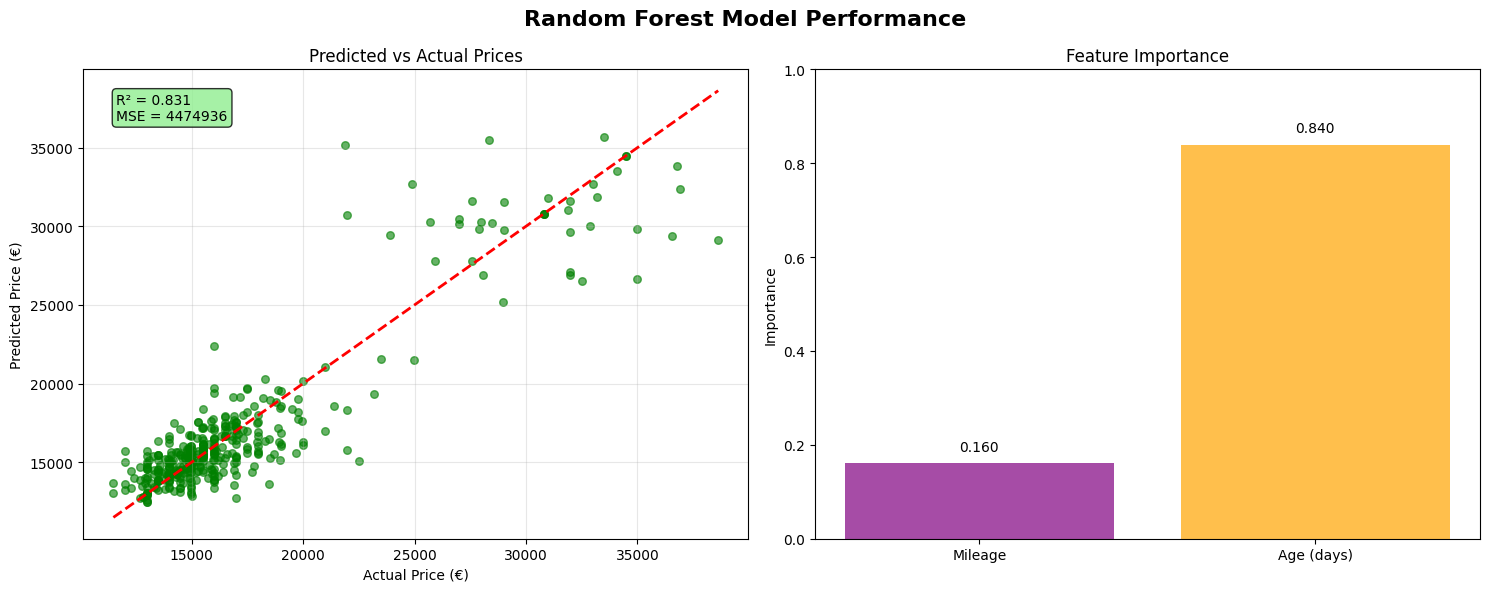

In [69]:
# Visualize Random Forest model performance
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Random Forest Model Performance', fontsize=16, fontweight='bold')

# Ensure we use the right data format for Random Forest (array format)
X_test_rf = test_df_top[['mileage', 'age_in_days']].values
y_test_rf = test_df_top['price'].values

# Predicted vs Actual scatter plot
y_pred_rf = rf.predict(X_test_rf)
axes[0].scatter(y_test_rf, y_pred_rf, alpha=0.6, color='green', s=30)
axes[0].plot([y_test_rf.min(), y_test_rf.max()], [y_test_rf.min(), y_test_rf.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Price (€)')
axes[0].set_ylabel('Predicted Price (€)')
axes[0].set_title('Predicted vs Actual Prices')
axes[0].grid(True, alpha=0.3)
axes[0].text(0.05, 0.95, f'R² = {rf_r2:.3f}\nMSE = {rf_mse:.0f}', 
             transform=axes[0].transAxes, bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8),
             verticalalignment='top')

# Feature importance
feature_importance_rf = rf.feature_importances_
feature_names = ['Mileage', 'Age (days)']
axes[1].bar(feature_names, feature_importance_rf, color=['purple', 'orange'], alpha=0.7)
axes[1].set_title('Feature Importance')
axes[1].set_ylabel('Importance')
axes[1].set_ylim(0, 1)
for i, v in enumerate(feature_importance_rf):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Training: Linear Regression (price = base_price - a * mileage - b * age_in_days)
Fit a linear regression for the top car model to estimate the coefficients a and b.

In [70]:
from sklearn.linear_model import LinearRegression
# Linear Regression for the top car model
X_train = train_df_top[['mileage', 'age_in_days']].values
y_train = train_df_top['price'].values
X_test = test_df_top[['mileage', 'age_in_days']].values
y_test = test_df_top['price'].values
linreg = LinearRegression()
linreg.fit(X_train, y_train)
y_pred = linreg.predict(X_test)
lin_mse = mean_squared_error(y_test, y_pred)
lin_r2 = r2_score(y_test, y_pred)
print(f"Linear Regression: base_price={linreg.intercept_:.2f}, a={linreg.coef_[0]:.4f}, b={linreg.coef_[1]:.4f}, MSE={lin_mse:.2f}, R2={lin_r2:.2f}")

Linear Regression: base_price=28153.55, a=-0.0369, b=-7.3391, MSE=8148179.43, R2=0.69


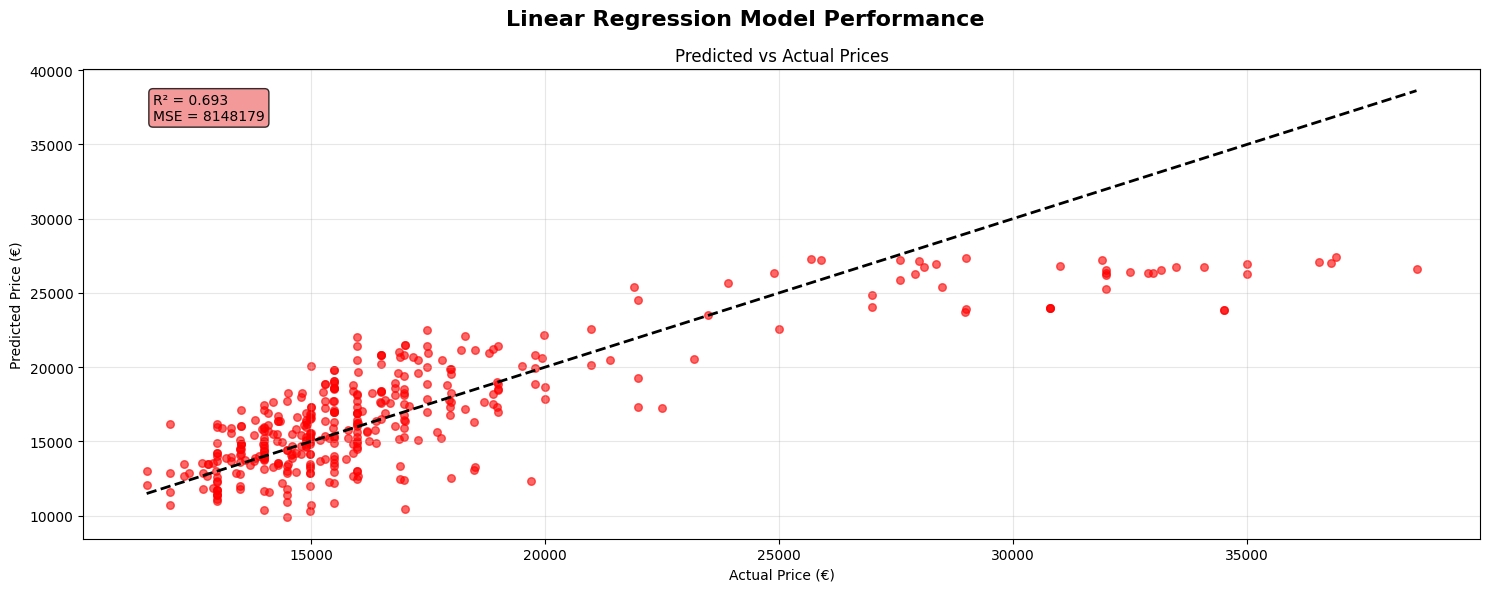

In [71]:
# Visualize Linear Regression model performance
fig, axes = plt.subplots(1, 1, figsize=(15, 6))
fig.suptitle('Linear Regression Model Performance', fontsize=16, fontweight='bold')

# Ensure we use the right data format for Linear Regression (array format)
X_test_lin = test_df_top[['mileage', 'age_in_days']].values
y_test_lin = test_df_top['price'].values

# Predicted vs Actual scatter plot
y_pred_lin = linreg.predict(X_test_lin)
axes.scatter(y_test_lin, y_pred_lin, alpha=0.6, color='red', s=30)
axes.plot([y_test_lin.min(), y_test_lin.max()], [y_test_lin.min(), y_test_lin.max()], 'k--', lw=2)
axes.set_xlabel('Actual Price (€)')
axes.set_ylabel('Predicted Price (€)')
axes.set_title('Predicted vs Actual Prices')
axes.grid(True, alpha=0.3)
axes.text(0.05, 0.95, f'R² = {lin_r2:.3f}\nMSE = {lin_mse:.0f}', 
             transform=axes.transAxes, bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.8),
             verticalalignment='top')

plt.tight_layout()
plt.show()

### Training: Exponential Curve Fitting (price = base_price * exp(-a * mileage) * exp(-b * age_in_days))
Fit an exponential regression for the top car model using curve fitting.

In [72]:
from scipy.optimize import curve_fit
import numpy as np
def nonlinear_func(X, base_price, a, b):
    mileage, age_in_days = X
    return base_price * np.exp(-a * mileage) * np.exp(-b * age_in_days)
# Nonlinear Regression for the top car model
X_train = train_df_top[['mileage', 'age_in_days']].values.T
y_train = train_df_top['price'].values
X_test = test_df_top[['mileage', 'age_in_days']].values.T
y_test = test_df_top['price'].values
try:
    popt, _ = curve_fit(nonlinear_func, X_train, y_train, p0=[np.mean(y_train), 1e-6, 1e-3], maxfev=10000)
    y_pred = nonlinear_func(X_test, *popt)
    nonlin_mse = mean_squared_error(y_test, y_pred)
    nonlin_r2 = r2_score(y_test, y_pred)
    print(f"Nonlinear Regression: base_price={popt[0]:.2f}, a={popt[1]:.6f}, b={popt[2]:.6f}, MSE={nonlin_mse:.2f}, R2={nonlin_r2:.2f}")
except Exception as e:
    print(f"Curve fit failed: {e}")

Nonlinear Regression: base_price=31571.72, a=0.000002, b=0.000417, MSE=6194662.05, R2=0.77


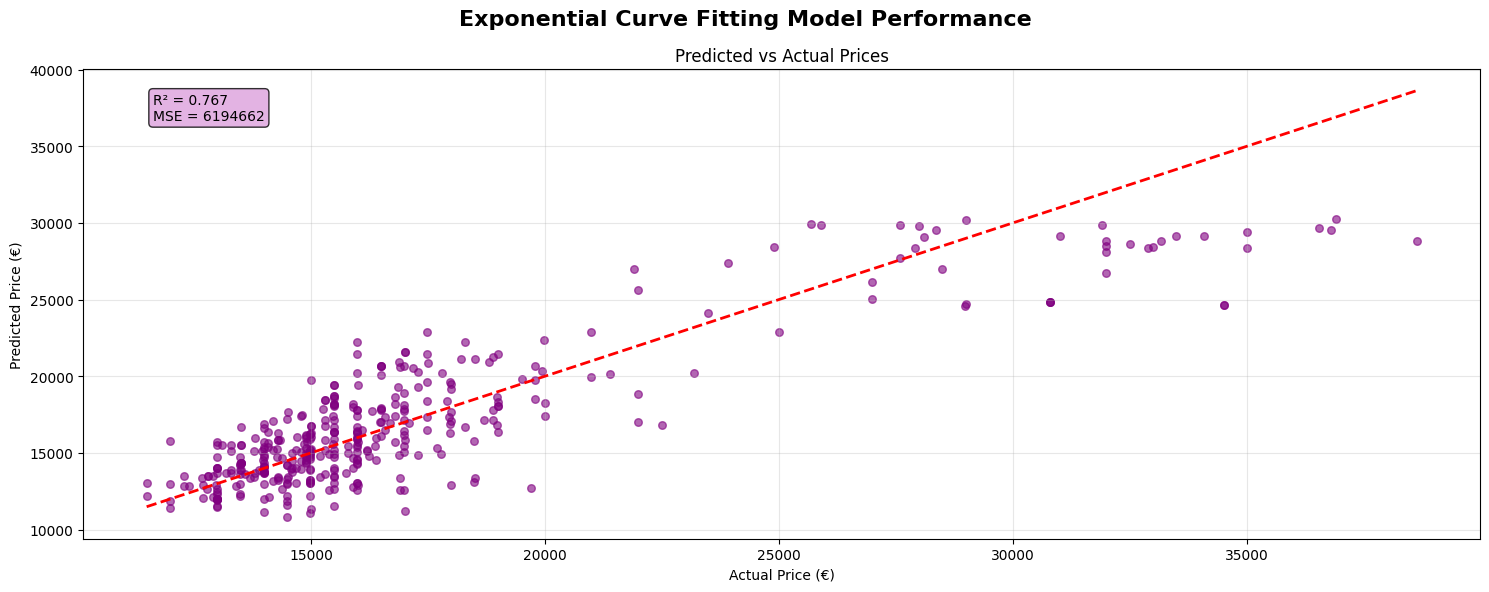

Exponential Model: Price = 31572 × exp(-2.47e-06 × mileage) × exp(-4.17e-04 × age_days)


In [73]:
# Visualize Exponential Curve Fitting model performance
if 'nonlin_mse' in locals() and 'nonlin_r2' in locals():
    fig, axes = plt.subplots(1, 1, figsize=(15, 6))
    fig.suptitle('Exponential Curve Fitting Model Performance', fontsize=16, fontweight='bold')
    
    # Ensure we use the right data format for Exponential (transposed array format)
    X_test_exp = test_df_top[['mileage', 'age_in_days']].values.T
    y_test_exp = test_df_top['price'].values
    
    # Predicted vs Actual scatter plot
    y_pred_exp = nonlinear_func(X_test_exp, *popt)
    axes.scatter(y_test_exp, y_pred_exp, alpha=0.6, color='purple', s=30)
    axes.plot([y_test_exp.min(), y_test_exp.max()], [y_test_exp.min(), y_test_exp.max()], 'r--', lw=2)
    axes.set_xlabel('Actual Price (€)')
    axes.set_ylabel('Predicted Price (€)')
    axes.set_title('Predicted vs Actual Prices')
    axes.grid(True, alpha=0.3)
    axes.text(0.05, 0.95, f'R² = {nonlin_r2:.3f}\nMSE = {nonlin_mse:.0f}', 
                 transform=axes.transAxes, bbox=dict(boxstyle='round', facecolor='plum', alpha=0.8),
                 verticalalignment='top')
    
    plt.tight_layout()
    plt.show()
    
    # Show the exponential function formula
    print(f"Exponential Model: Price = {popt[0]:.0f} × exp(-{popt[1]:.2e} × mileage) × exp(-{popt[2]:.2e} × age_days)")
else:
    print("Exponential curve fitting failed - no visualization available")

### Training: Mixed Exponential-Linear Model (Weighted Ensemble)
Combine exponential and linear regression predictions using an optimized weight parameter α for potentially better performance.

Use curve fitting to compute the best parameters of the linear and exp parts, as well as the alpha coef so that: model = alpha * linear_model + (1-alpha) * exponential_model

In [74]:
from scipy.optimize import curve_fit
import numpy as np
def mixedmodel_func(X, base_price_lin, a_lin, b_lin, base_price_exp, a_exp, b_exp, alpha):
    mileage, age_in_days = X
    return alpha * (base_price_lin + a_lin * mileage + b_lin * age_in_days) + \
           (1 - alpha) * (base_price_exp * np.exp(-a_exp * mileage) * np.exp(-b_exp * age_in_days))

# Nonlinear Regression for the top car model
X_train = train_df_top[['mileage', 'age_in_days']].values.T
y_train = train_df_top['price'].values
X_test = test_df_top[['mileage', 'age_in_days']].values.T
y_test = test_df_top['price'].values

try:
    popt_mixedmodel, _ = curve_fit(mixedmodel_func, X_train, y_train, maxfev=10000, 
                                   p0=[np.mean(y_train), 1e-6, 1e-3, np.mean(y_train), 1e-6, 1e-3, 0.5])
    y_pred = mixedmodel_func(X_test, *popt_mixedmodel)
    mixed_mse = mean_squared_error(y_test, y_pred)
    mixed_r2 = r2_score(y_test, y_pred)
    
    # Extract optimized coefficients
    base_price_lin, a_lin, b_lin, base_price_exp, a_exp, b_exp, alpha = popt_mixedmodel
    
    print("Mixed Model Curve Fitting Results:")
    print(f"Alpha (weight): {alpha:.6f}")
    print(f"Linear part: base_price={base_price_lin:.2f}, a={a_lin:.6f}, b={b_lin:.6f}")
    print(f"Exponential part: base_price={base_price_exp:.2f}, a={a_exp:.6f}, b={b_exp:.6f}")
    print(f"Performance: MSE={mixed_mse:.2f}, R²={mixed_r2:.3f}")
    print(f"\nMixed Model Formula:")
    print(f"Price = {alpha:.3f} × ({base_price_lin:.0f} + {a_lin:.2e} × mileage + {b_lin:.2e} × age_days)")
    print(f"      + {1-alpha:.3f} × ({base_price_exp:.0f} × exp(-{a_exp:.2e} × mileage) × exp(-{b_exp:.2e} × age_days))")
    
except Exception as e:
    print(f"Curve fit failed: {e}")

Mixed Model Curve Fitting Results:
Alpha (weight): 0.386256
Linear part: base_price=-23513.67, a=0.079321, b=16.917249
Exponential part: base_price=73798.89, a=0.000005, b=0.000678
Performance: MSE=4672311.27, R²=0.824

Mixed Model Formula:
Price = 0.386 × (-23514 + 7.93e-02 × mileage + 1.69e+01 × age_days)
      + 0.614 × (73799 × exp(-5.49e-06 × mileage) × exp(-6.78e-04 × age_days))


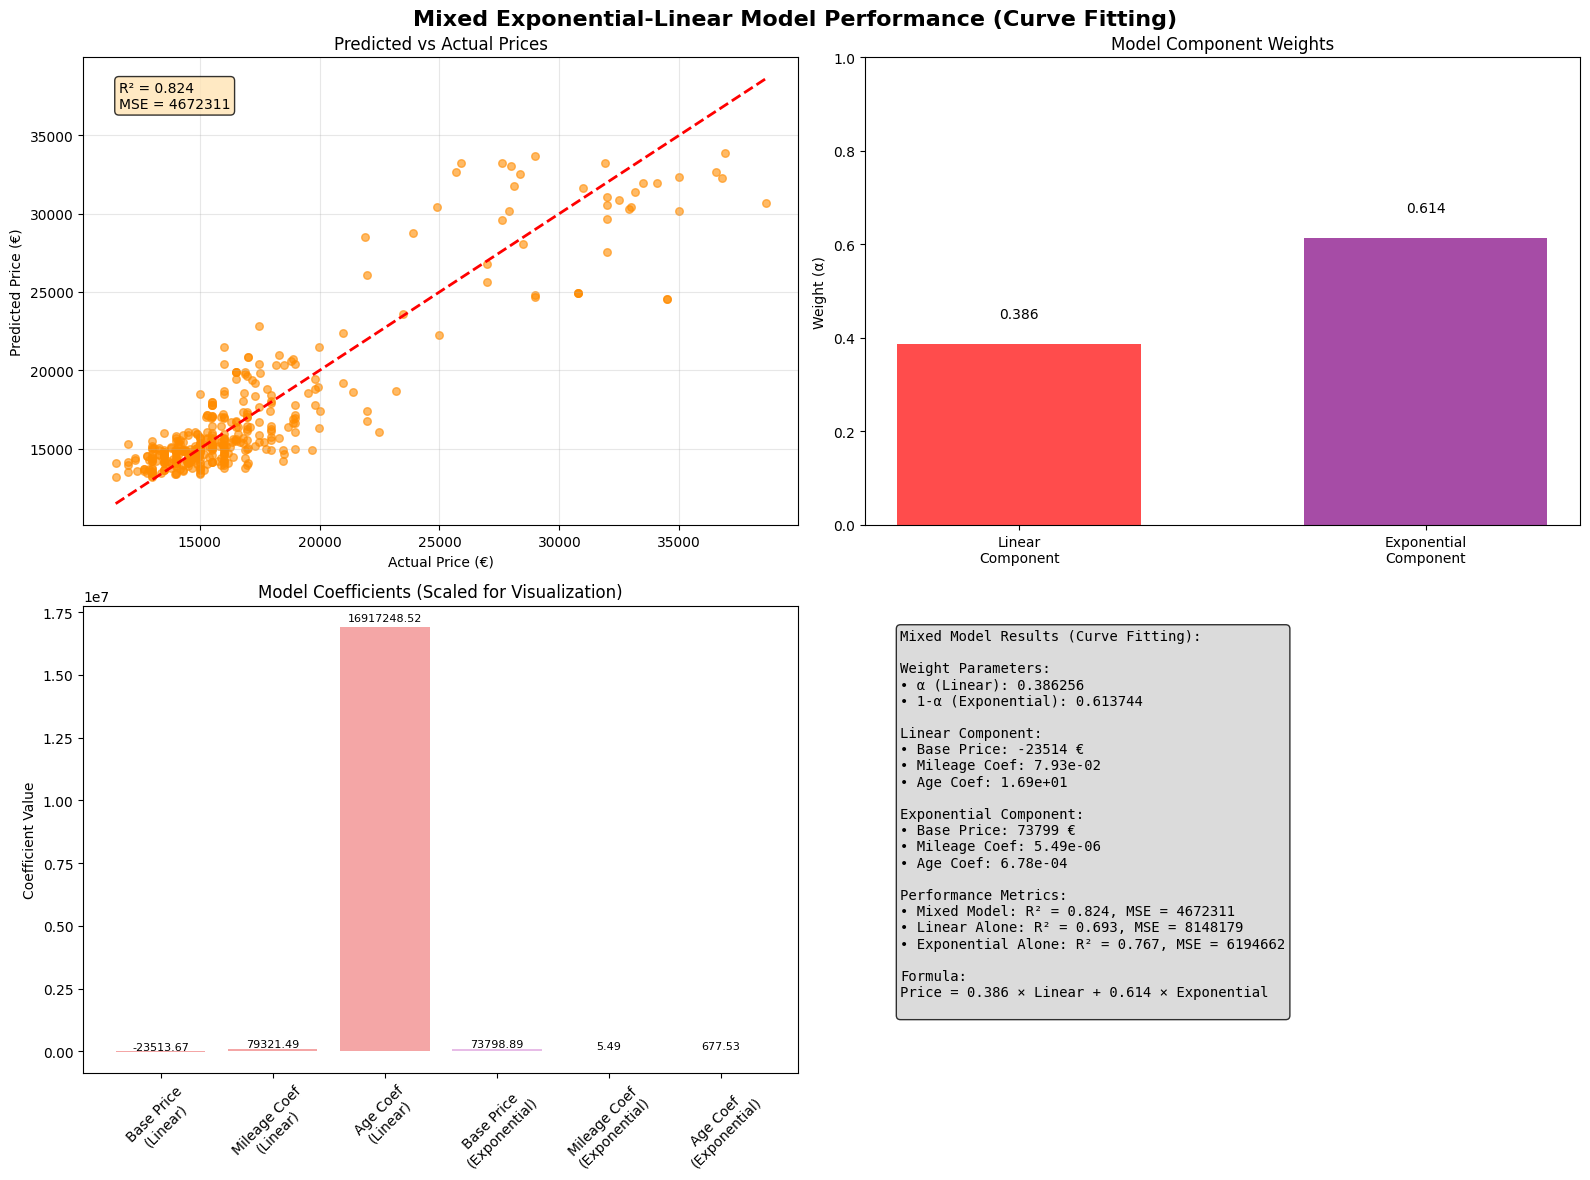


Mixed Model Component Analysis:
Linear component contribution: 38.6%
Exponential component contribution: 61.4%
The model is more exponential-dominated (α = 0.386)


In [75]:
# Visualize Mixed Model performance (Curve Fitting Approach)
if 'mixed_mse' in locals() and mixed_mse is not None and 'popt_mixedmodel' in locals():
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Mixed Exponential-Linear Model Performance (Curve Fitting)', fontsize=16, fontweight='bold')
    
    # Extract coefficients for visualization
    base_price_lin, a_lin, b_lin, base_price_exp, a_exp, b_exp, alpha_weight = popt_mixedmodel
    
    # Predicted vs Actual scatter plot
    axes[0, 0].scatter(y_test, y_pred, alpha=0.6, color='darkorange', s=30)
    axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[0, 0].set_xlabel('Actual Price (€)')
    axes[0, 0].set_ylabel('Predicted Price (€)')
    axes[0, 0].set_title('Predicted vs Actual Prices')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].text(0.05, 0.95, f'R² = {mixed_r2:.3f}\nMSE = {mixed_mse:.0f}', 
                     transform=axes[0, 0].transAxes, bbox=dict(boxstyle='round', facecolor='moccasin', alpha=0.8),
                     verticalalignment='top')
    
    # Weight analysis bar chart
    axes[0, 1].bar(['Linear\nComponent', 'Exponential\nComponent'], [alpha_weight, 1-alpha_weight], 
                    color=['red', 'purple'], alpha=0.7, width=0.6)
    axes[0, 1].set_title('Model Component Weights')
    axes[0, 1].set_ylabel('Weight (α)')
    axes[0, 1].set_ylim(0, 1)
    axes[0, 1].text(0, alpha_weight + 0.05, f'{alpha_weight:.3f}', ha='center', va='bottom')
    axes[0, 1].text(1, (1-alpha_weight) + 0.05, f'{1-alpha_weight:.3f}', ha='center', va='bottom')
    
    # Coefficient comparison visualization
    coef_names = ['Base Price\n(Linear)', 'Mileage Coef\n(Linear)', 'Age Coef\n(Linear)', 
                  'Base Price\n(Exponential)', 'Mileage Coef\n(Exponential)', 'Age Coef\n(Exponential)']
    coef_values = [base_price_lin, a_lin*1e6, b_lin*1e6, base_price_exp, a_exp*1e6, b_exp*1e6]  # Scale small coefficients
    colors_coef = ['lightcoral', 'lightcoral', 'lightcoral', 'plum', 'plum', 'plum']
    
    bars = axes[1, 0].bar(coef_names, coef_values, color=colors_coef, alpha=0.7)
    axes[1, 0].set_title('Model Coefficients (Scaled for Visualization)')
    axes[1, 0].set_ylabel('Coefficient Value')
    axes[1, 0].tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for bar, val in zip(bars, coef_values):
        height = bar.get_height()
        axes[1, 0].text(bar.get_x() + bar.get_width()/2., height + abs(height)*0.01,
                        f'{val:.2f}' if abs(val) > 1 else f'{val:.2e}',
                        ha='center', va='bottom', fontsize=8)
    
    # Performance comparison and formula display
    axes[1, 1].axis('off')
    comparison_text = f"""Mixed Model Results (Curve Fitting):

Weight Parameters:
• α (Linear): {alpha_weight:.6f}
• 1-α (Exponential): {1-alpha_weight:.6f}

Linear Component:
• Base Price: {base_price_lin:.0f} €
• Mileage Coef: {a_lin:.2e}
• Age Coef: {b_lin:.2e}

Exponential Component:
• Base Price: {base_price_exp:.0f} €
• Mileage Coef: {a_exp:.2e}
• Age Coef: {b_exp:.2e}

Performance Metrics:
• Mixed Model: R² = {mixed_r2:.3f}, MSE = {mixed_mse:.0f}
• Linear Alone: R² = {lin_r2:.3f}, MSE = {lin_mse:.0f}
• Exponential Alone: R² = {nonlin_r2:.3f}, MSE = {nonlin_mse:.0f}

Formula:
Price = {alpha_weight:.3f} × Linear + {1-alpha_weight:.3f} × Exponential
"""
    
    axes[1, 1].text(0.05, 0.95, comparison_text, transform=axes[1, 1].transAxes, fontsize=10,
                    verticalalignment='top', fontfamily='monospace',
                    bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    # Show component contributions
    print(f"\nMixed Model Component Analysis:")
    print(f"Linear component contribution: {alpha_weight:.1%}")
    print(f"Exponential component contribution: {(1-alpha_weight):.1%}")
    
    if alpha_weight > 0.5:
        print(f"The model is more linear-dominated (α = {alpha_weight:.3f})")
    elif alpha_weight < 0.5:
        print(f"The model is more exponential-dominated (α = {alpha_weight:.3f})")
    else:
        print(f"The model is balanced between linear and exponential (α = {alpha_weight:.3f})")
        
else:
    print("Mixed model visualization not available - model creation may have failed or variables not found")

### Model Comparison
Compare the performance of all regression models for the car model with the most records using MSE and R² metrics.

In [76]:
# Model Comparison for the top car model
comparison = {
    'Model': top_model,
    'GradientBoosting_MSE': gb_mse,
    'GradientBoosting_R2': gb_r2,
    'RandomForest_MSE': rf_mse,
    'RandomForest_R2': rf_r2,
    'Linear_MSE': lin_mse,
    'Linear_R2': lin_r2,
    'Exponential_MSE': nonlin_mse if 'nonlin_mse' in locals() else None,
    'Exponential_R2': nonlin_r2 if 'nonlin_r2' in locals() else None,
    'Mixed_MSE': mixed_mse if 'mixed_mse' in locals() and mixed_mse is not None else None,
    'Mixed_R2': mixed_r2 if 'mixed_r2' in locals() and mixed_r2 is not None else None
}

comparison_df = pd.DataFrame([comparison])
print("Model Performance Comparison:")
comparison_df

Model Performance Comparison:


,Model,GradientBoosting_MSE,GradientBoosting_R2,RandomForest_MSE,RandomForest_R2,Linear_MSE,Linear_R2,Exponential_MSE,Exponential_R2,Mixed_MSE,Mixed_R2
0,PEUGEOT_208,4.199395e+06,0.841814,4.474936e+06,0.831435,8.148179e+06,0.693068,6.194662e+06,0.766655,4.672311e+06,0.824


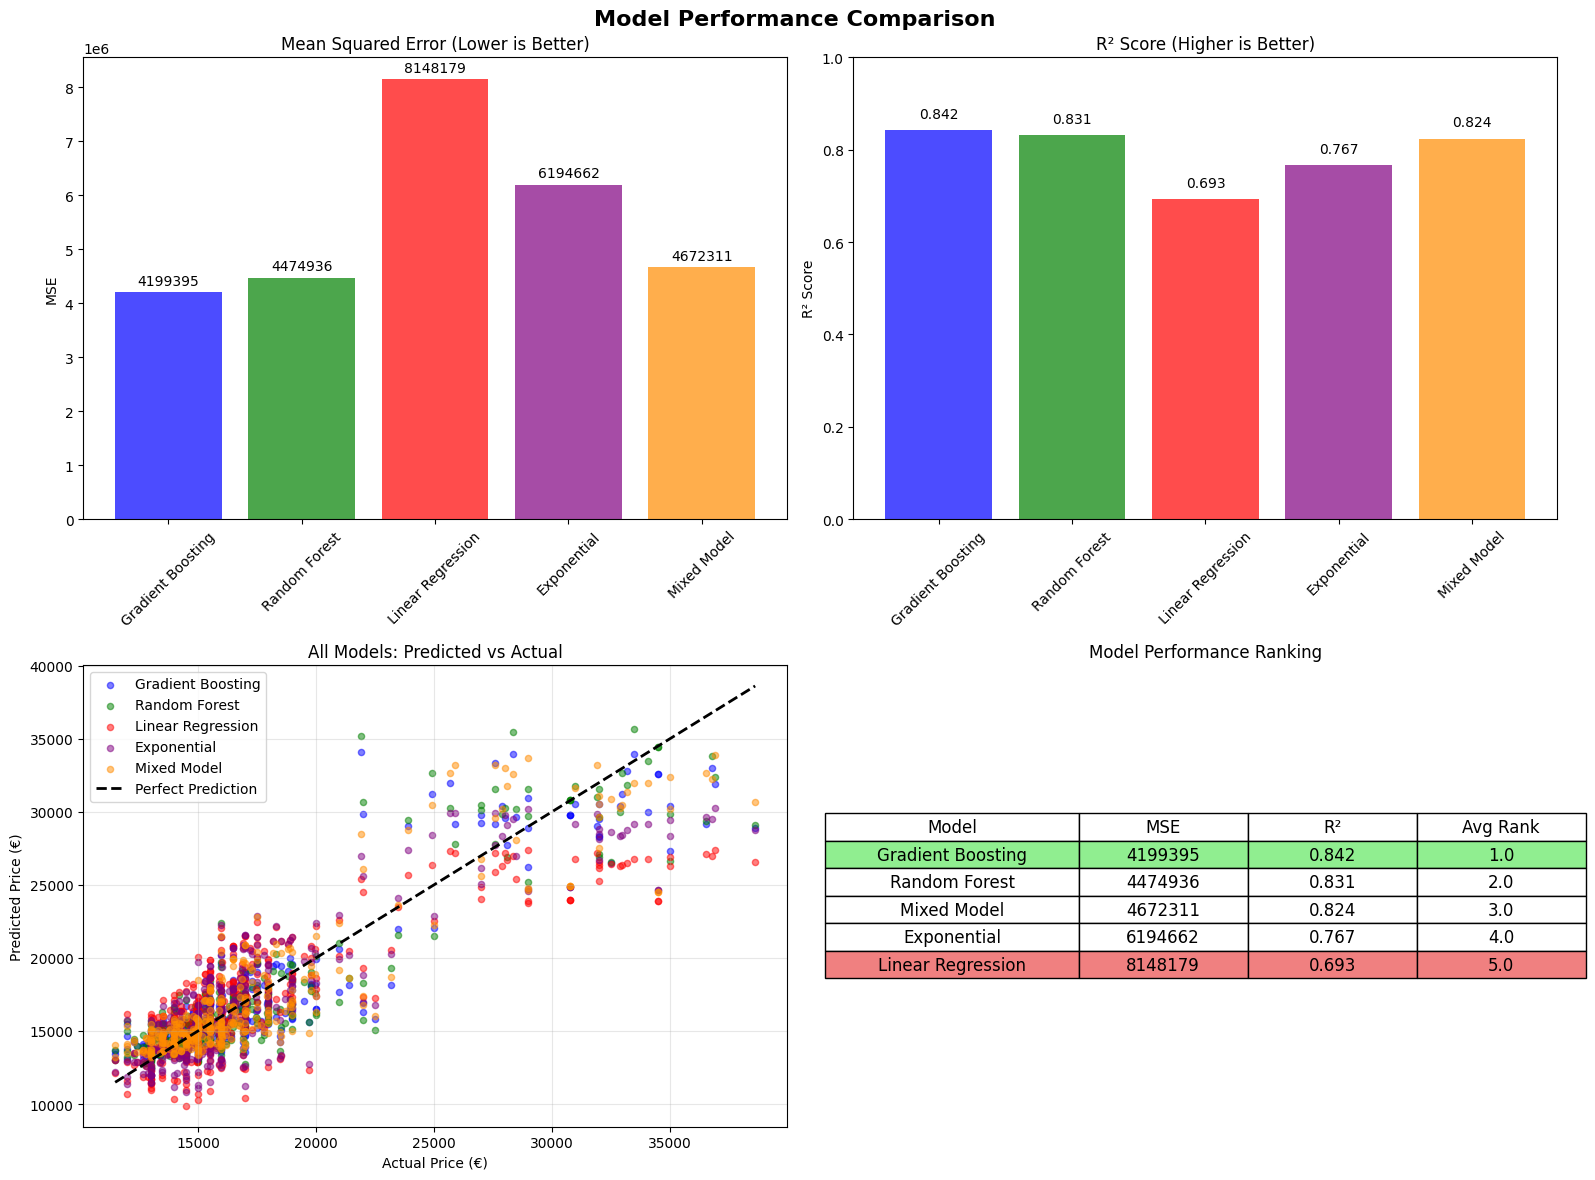


Best performing model: Gradient Boosting
Ranking based on average of MSE rank and R² rank (lower is better)

Mixed Model Details (Curve Fitting):
  α (linear weight): 0.386256
  1-α (exponential weight): 0.613744
  Linear: -23514 + 7.93e-02 × mileage + 1.69e+01 × age_days
  Exponential: 73799 × exp(-5.49e-06 × mileage) × exp(-6.78e-04 × age_days)
  Formula: Price = 0.386 × Linear + 0.614 × Exponential


In [77]:
# Comprehensive Model Comparison Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

# Prepare data for comparison
models = ['Gradient Boosting', 'Random Forest', 'Linear Regression']
mse_scores = [gb_mse, rf_mse, lin_mse]
r2_scores = [gb_r2, rf_r2, lin_r2]
colors = ['blue', 'green', 'red']

# Add exponential if available
if 'nonlin_mse' in locals() and 'nonlin_r2' in locals():
    models.append('Exponential')
    mse_scores.append(nonlin_mse)
    r2_scores.append(nonlin_r2)
    colors.append('purple')

# Add mixed model if available
if 'mixed_mse' in locals() and mixed_mse is not None:
    models.append('Mixed Model')
    mse_scores.append(mixed_mse)
    r2_scores.append(mixed_r2)
    colors.append('darkorange')

# MSE Comparison
axes[0, 0].bar(models, mse_scores, color=colors, alpha=0.7)
axes[0, 0].set_title('Mean Squared Error (Lower is Better)')
axes[0, 0].set_ylabel('MSE')
axes[0, 0].tick_params(axis='x', rotation=45)
for i, v in enumerate(mse_scores):
    axes[0, 0].text(i, v + max(mse_scores)*0.01, f'{v:.0f}', ha='center', va='bottom')

# R² Comparison
axes[0, 1].bar(models, r2_scores, color=colors, alpha=0.7)
axes[0, 1].set_title('R² Score (Higher is Better)')
axes[0, 1].set_ylabel('R² Score')
axes[0, 1].set_ylim(0, 1)
axes[0, 1].tick_params(axis='x', rotation=45)
for i, v in enumerate(r2_scores):
    axes[0, 1].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom')

# Combined predictions vs actual (all models) - using consistent data formats
y_test_viz = test_df_top['price'].values

# Get predictions using appropriate data formats for each model
y_pred_gb_viz = gb_reg.predict(test_df_top[['age_in_days', 'mileage']])  # DataFrame format
y_pred_rf_viz = rf.predict(test_df_top[['mileage', 'age_in_days']].values)  # Array format
y_pred_lin_viz = linreg.predict(test_df_top[['mileage', 'age_in_days']].values)  # Array format

axes[1, 0].scatter(y_test_viz, y_pred_gb_viz, alpha=0.5, color='blue', s=20, label='Gradient Boosting')
axes[1, 0].scatter(y_test_viz, y_pred_rf_viz, alpha=0.5, color='green', s=20, label='Random Forest')
axes[1, 0].scatter(y_test_viz, y_pred_lin_viz, alpha=0.5, color='red', s=20, label='Linear Regression')

if 'nonlin_mse' in locals():
    y_pred_exp_viz = nonlinear_func(test_df_top[['mileage', 'age_in_days']].values.T, *popt)  # Transposed array format
    axes[1, 0].scatter(y_test_viz, y_pred_exp_viz, alpha=0.5, color='purple', s=20, label='Exponential')

# Generate mixed model predictions for comparison visualization (curve fitting approach)
if 'mixed_mse' in locals() and mixed_mse is not None and 'popt_mixedmodel' in locals():
    y_pred_mixed_viz = mixedmodel_func(test_df_top[['mileage', 'age_in_days']].values.T, *popt_mixedmodel)
    axes[1, 0].scatter(y_test_viz, y_pred_mixed_viz, alpha=0.5, color='darkorange', s=20, label='Mixed Model')

axes[1, 0].plot([y_test_viz.min(), y_test_viz.max()], [y_test_viz.min(), y_test_viz.max()], 'k--', lw=2, label='Perfect Prediction')
axes[1, 0].set_xlabel('Actual Price (€)')
axes[1, 0].set_ylabel('Predicted Price (€)')
axes[1, 0].set_title('All Models: Predicted vs Actual')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Model ranking
performance_df = pd.DataFrame({
    'Model': models,
    'MSE': mse_scores,
    'R²': r2_scores,
    'MSE_Rank': pd.Series(mse_scores).rank(method='min'),
    'R²_Rank': pd.Series(r2_scores).rank(method='min', ascending=False)
})
performance_df['Average_Rank'] = (performance_df['MSE_Rank'] + performance_df['R²_Rank']) / 2
performance_df = performance_df.sort_values('Average_Rank')

axes[1, 1].axis('off')
table_data = []
for _, row in performance_df.iterrows():
    table_data.append([
        row['Model'],
        f"{row['MSE']:.0f}",
        f"{row['R²']:.3f}",
        f"{row['Average_Rank']:.1f}"
    ])

table = axes[1, 1].table(cellText=table_data,
                        colLabels=['Model', 'MSE', 'R²', 'Avg Rank'],
                        cellLoc='center',
                        loc='center',
                        colWidths=[0.3, 0.2, 0.2, 0.2])
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.5)
axes[1, 1].set_title('Model Performance Ranking')

# Color code the table rows
for i in range(len(table_data)):
    if i == 0:  # Best model
        for j in range(4):
            table[(i+1, j)].set_facecolor('lightgreen')
    elif i == len(table_data) - 1:  # Worst model
        for j in range(4):
            table[(i+1, j)].set_facecolor('lightcoral')

plt.tight_layout()
plt.show()

print(f"\nBest performing model: {performance_df.iloc[0]['Model']}")
print(f"Ranking based on average of MSE rank and R² rank (lower is better)")

# Show mixed model details if available (curve fitting approach)
if 'mixed_mse' in locals() and mixed_mse is not None and 'popt_mixedmodel' in locals():
    base_price_lin_final, a_lin_final, b_lin_final, base_price_exp_final, a_exp_final, b_exp_final, alpha_final = popt_mixedmodel
    print(f"\nMixed Model Details (Curve Fitting):")
    print(f"  α (linear weight): {alpha_final:.6f}")
    print(f"  1-α (exponential weight): {1-alpha_final:.6f}")
    print(f"  Linear: {base_price_lin_final:.0f} + {a_lin_final:.2e} × mileage + {b_lin_final:.2e} × age_days")
    print(f"  Exponential: {base_price_exp_final:.0f} × exp(-{a_exp_final:.2e} × mileage) × exp(-{b_exp_final:.2e} × age_days)")
    print(f"  Formula: Price = {alpha_final:.3f} × Linear + {1-alpha_final:.3f} × Exponential")